<a href="https://colab.research.google.com/github/VielF/ColabProjects/blob/main/Pr%C3%A1tica_Processamento_Morfol%C3%B3gico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from main import *

main()

Universidade do Vale do Itajaí<br>
Escola Politécnica<br>
Processamento Digital de Sinais: Imagens

# Exercício Avalitivo de Processamento Morfológico

### Tutoriais da OpenCV

- https://docs.opencv.org/master/d9/df8/tutorial_root.html
- https://www.geeksforgeeks.org/opencv-python-tutorial/

## Processamento Morfológico
#### Obs: Utilize imagens em preto e branco.


### Erosão e Dilatação

1. Implemente a sua própria versão da erosão em formato de função, com capacidade de trabalhar com diferentes elementos estruturantes (tamanho e forma) e aplique o algoritmos na na figura ImagensMorfologia/Fig0905(a)(wirebond-mask)
2. Implemente a sua própria versão da dilatação em formato de função, com capacidade de trabalhar com diferentes elementos estruturantes (tamanho e forma) e aplique o algoritmos na na figura ImagensMorfologia/Fig0907(a)(text_gaps_1_and_2_pixels)
4. Relate as observações visíveis nas imagens de saída com os processamentos aplicados, descrevendo o comportamento visual em relação as bordas, junção, perda de informação e mlhoria na qualidade visual.
5. Aplique o seu algoritmo de detecção de borda (roberts ou sobel) a imagem ImagensMorfologia/Fig0905(a)(wirebond-mask) antes e depois de utilizar a dilatação/erosão e relate os resultados.

#### Dicas
 - Você pode adicionar ruído nas imagens usando a função random_noise: `from skimage.util import random_noise`. Cuidado com o retorno da função, talvez seja necessário regularizar a mesma novamente para o intervalo de 0 à 255. O ruído pode ser intensificado ou excluído com processamento morfológico.

In [3]:
#Kernel
def criar_kernel(formato="quadrado", tamanho=3):

    """
    Cria elementos estruturantes para operações morfológicas.
    Formatos:
    - "quadrado"
    - "cruz"
    - "circulo"
    - "retangulo
    """
    if isinstance(tamanho, int):
        altura = largura = tamanho
    else:
        altura, largura = tamanho

    if altura % 2 == 0 or largura % 2 == 0:
        raise ValueError("Valor invalido pro kernel, use valores ímpars")

    if formato == "quadrado":
        kernel = np.ones((altura, largura), dtype=np.uint8)

    elif formato == "cruz":
        kernel = np.zeros((altura, largura), dtype=np.uint8)

        centro_y = altura // 2
        centro_x = largura // 2

        kernel[centro_y, :] = 1
        kernel[:, centro_x] = 1

    elif formato == "circulo":
        kernel = np.zeros((altura, largura), dtype=np.uint8)

        centro = tamanho // 2
        raio = centro

        for y in range(altura):
            for x in range(largura):
                distancia = np.sqrt((y - centro) ** 2 + (x - centro) ** 2)

                if distancia <= raio:
                    kernel[y, x] = 1

    elif formato == "retangulo":
        kernel = np.ones((altura, largura), dtype=np.uint8)

    return kernel

In [4]:
#Erosão
def erosao(img, kernel, objeto="preto"):
    """
    Aplica erosão em uma imagem limiarizada.

    objeto:
    - "branco": considera pixels brancos
    - "preto": considera pixels pretos
    """

    img = (img > 0).astype(np.uint8)
    k = (kernel > 0).astype(np.uint8)

    altura, largura = img.shape
    kh, kw = k.shape

    pad_y = kh // 2
    pad_x = kw // 2

    if objeto == "branco":
        valor_objeto = 1
        valor_fundo = 0

    elif objeto == "preto":
        valor_objeto = 0
        valor_fundo = 1

    #padding com valor de fundo
    img_padded = np.pad(
        img,
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode="constant",
        constant_values=valor_fundo
    )

    #Resultado começa preenchido com fundo
    resultado = np.full_like(img, valor_fundo, dtype=np.uint8)

    #percorre a imagem
    for y in range(altura):
        for x in range(largura):

            img_igual_kernel = True

            #percorre o kernel
            for i_kernel in range(kh):
                for j_kernel in range(kw):

                    if k[i_kernel, j_kernel] == 1:

                        pixel = img_padded[y + i_kernel, x + j_kernel]

                        #confere se o pixel não bate com o kernel
                        if pixel != valor_objeto:
                            img_igual_kernel = False

            if img_igual_kernel == True:
                resultado[y, x] = valor_objeto
            else:
                resultado[y, x] = valor_fundo

    resultado = resultado * 255
    resultado = resultado.astype(np.uint8)

    return resultado

In [5]:
#Dilatação
def dilatacao(img, kernel, objeto="preto"):
    """
    Aplica dilatação em uma imagem limiarizada.

    objeto:
    - "branco": considera pixels brancos
    - "preto": considera pixels pretos
    """

    img = (img > 0).astype(np.uint8)
    k = (kernel > 0).astype(np.uint8)

    altura, largura = img.shape
    kh, kw = k.shape

    pad_y = kh // 2
    pad_x = kw // 2

    if objeto == "branco":
        valor_objeto = 1
        valor_fundo = 0

    elif objeto == "preto":
        valor_objeto = 0
        valor_fundo = 1

    #padding com valor de fundo
    img_padded = np.pad(
        img,
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode="constant",
        constant_values=valor_fundo
    )

    #Resultado começa preenchido com fundo
    resultado = np.full_like(img, valor_fundo, dtype=np.uint8)

    #percorre a imagem
    for y in range(altura):
        for x in range(largura):

            encontrou_objeto = False

            #percorre o kernel
            for i_kernel in range(kh):
                for j_kernel in range(kw):

                    if k[i_kernel, j_kernel] == 1:

                        pixel = img_padded[y + i_kernel, x + j_kernel]

                        #confere se o pixel não bate com o kernel
                        if pixel == valor_objeto:
                            encontrou_objeto = True

            if encontrou_objeto == True:
                resultado[y, x] = valor_objeto
            else:
                resultado[y, x] = valor_fundo

    resultado = resultado * 255
    resultado = resultado.astype(np.uint8)

    return resultado

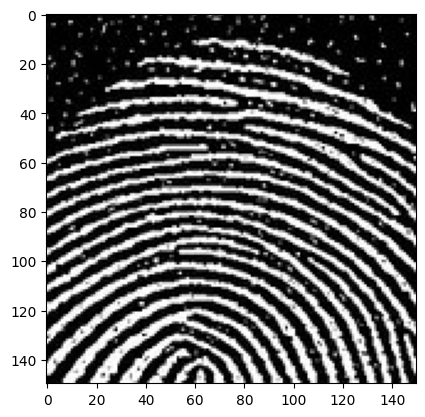

Shape before limiar (688, 688)


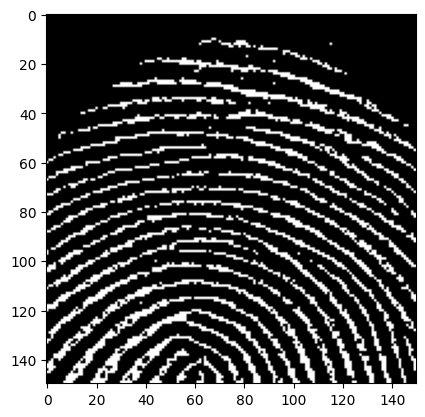

In [24]:
#Importar as imagens
img_wirebondmask = cv2.imread("data/test/aa.png",1)
img_text_gaps = cv2.imread("data/test/finger_print.jpg",1)

#Não vi que as imagens já estavam limiarizadas, mas fica aqui a ideia
#Aparentemente as imagens estão limiarizadas visualmente, mas não em formato, mantive as transformações pra evitar erros de shape

#Grayscale
B, G, R = cv2.split(img_wirebondmask)
img_gs_pondered = 0.114*B+0.587*G+0.299*R
img_wirebondmask = np.array(img_gs_pondered)
#cv2_imshow(img_wirebondmask)

B, G, R = cv2.split(img_text_gaps)
img_gs_pondered = 0.114*B+0.587*G+0.299*R
img_text_gaps = np.array(img_gs_pondered)

plt.imshow(img_text_gaps, cmap='gray')
plt.show()

print(f"Shape before limiar {img_wirebondmask.shape}")
#Limiar

limiar = 240
img_in = img_text_gaps.copy()
img_out = np.zeros(img_in.shape)

for i in range(img_in.shape[0]):
    for j in range(img_in.shape[1]):
        if img_in[i, j] > limiar:
            img_out[i, j] = 255
        else:
            img_out[i, j] = 0

img_text_gaps = img_out.copy()
img_out = img_out.astype(np.uint8)
plt.imshow(img_out, cmap='gray')
plt.show()

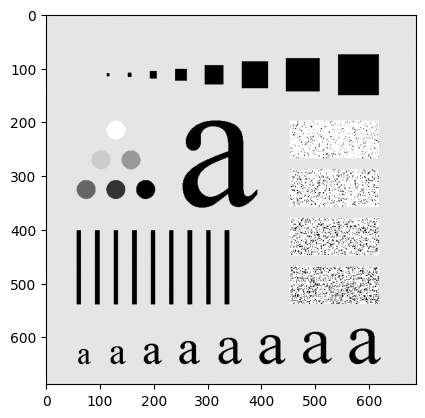

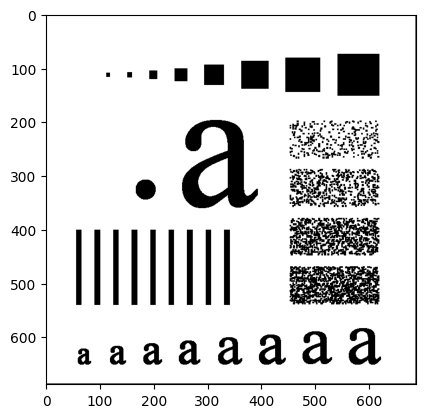

In [25]:
#Teste erosão - funcionando
kernel = criar_kernel(formato="quadrado", tamanho=3)
img_ero = erosao(img_wirebondmask, kernel, "branco")

plt.imshow(img_wirebondmask, cmap='gray')
plt.show()

plt.imshow(img_ero, cmap='gray')
plt.show()


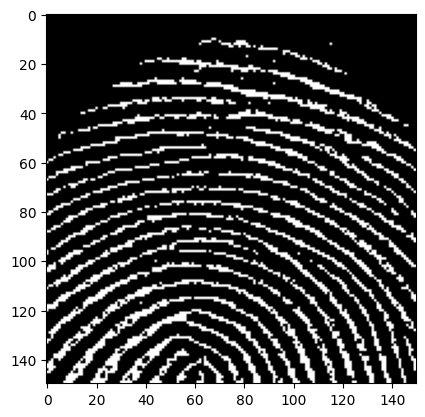

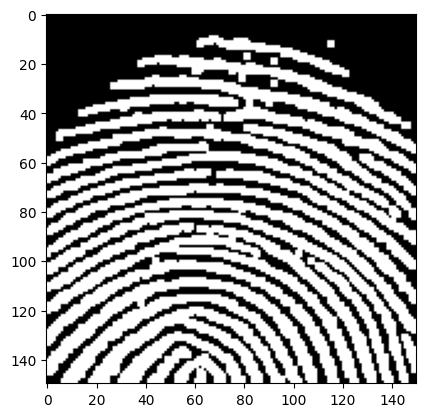

In [26]:
#Teste dilatação - funcionando
kernel = criar_kernel(formato="quadrado", tamanho=3)
img_dil = dilatacao(img_text_gaps, kernel, "branco")
plt.imshow(img_text_gaps, cmap='gray')
plt.show()

plt.imshow(img_dil, cmap='gray')
plt.show()


In [62]:
#COMENTÁRIOS
# A principio os algoritmos funcionaram corretamente, tive apenas uma problema de lógica no momento
# da implementação pois não me dei conta de imagens que poderiam ter fundo preto e objetos brancos, mas consegui reolver
# No geral o kernel quadrado 3x3 parece dar conta

### Abertura e Fechamento

5. Implemente a sua versão do algoritmo de abertura em forma de função com capacidade de trabalhar com diferentes elementos estruturantes (tamanho e forma)
6. Implemente a sua versão do algoritmo de fechamento em forma de função com capacidade de trabalhar com diferentes elementos estruturantes (tamanho e forma)
7. Aplique o processamento indicado na image abaixo usando a figura ImagensMorfologia/Fig0911(a)(noisy_fingerprint)

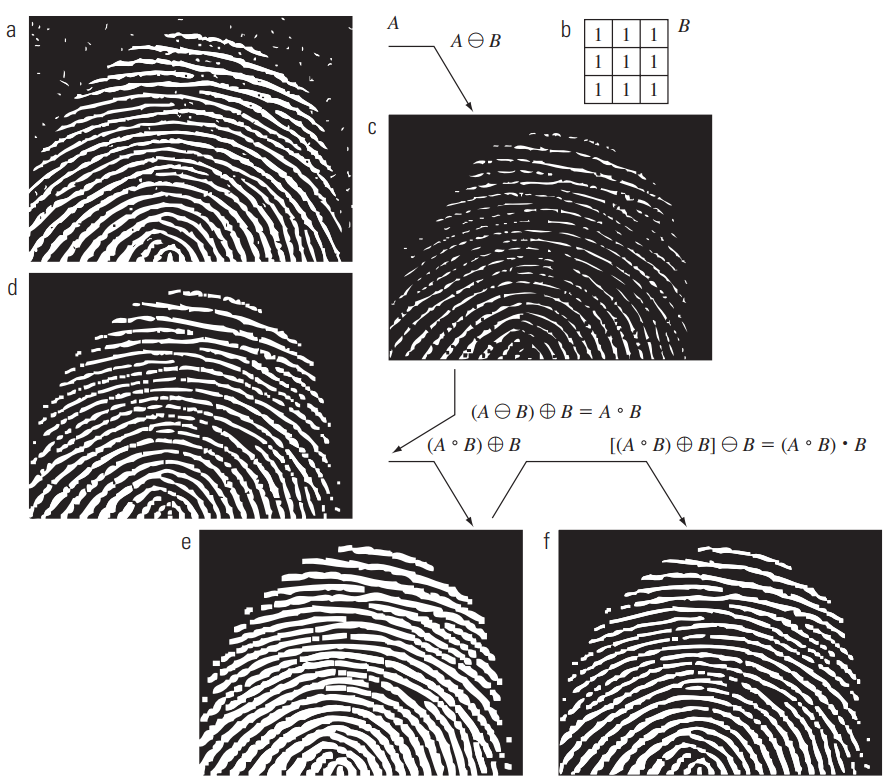

In [15]:
#Abertura
def abertura(img, kernel, objeto="branco"):
    """
    Aplica abertura em uma imagem limiarizada.

    Abertura = erosão + dilatação.
    """
    img_erodida = erosao(img, kernel, objeto)
    img_aberta = dilatacao(img_erodida, kernel, objeto)

    return img_aberta

In [16]:
#Fechamento
def fechamento(img, kernel, objeto="branco"):
    """
    Aplica fechamento em uma imagem limiarizada.

    Fechamento = dilatação + erosão.
    """
    img_dilatada = dilatacao(img, kernel, objeto)
    img_fechada = erosao(img_dilatada, kernel, objeto)

    return img_fechada

In [27]:
img_fingerprint = cv2.imread("data/test/moon.jpeg")

#Grayscale
B, G, R = cv2.split(img_fingerprint)
img_gs_pondered = 0.114*B+0.587*G+0.299*R
img_fingerprint = np.array(img_gs_pondered)
#cv2_imshow(img_fingerprint)

#Limiar
limiar = 127
img_in = img_fingerprint.copy()
img_out = np.zeros(img_in.shape)

for i in range(img_in.shape[0]):
    for j in range(img_in.shape[1]):
        if img_in[i, j] > limiar:
            img_out[i, j] = 255
        else:
            img_out[i, j] = 0

img_fingerprint = img_out.copy()
img_out = img_out.astype(np.uint8)
#cv2_imshow(img_out)

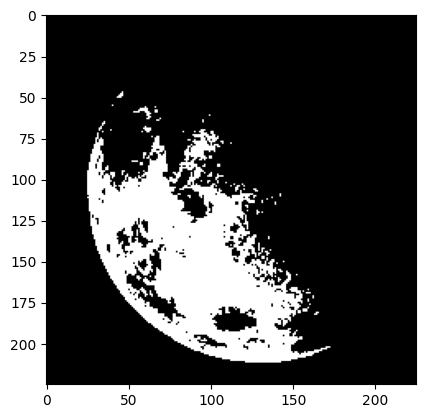

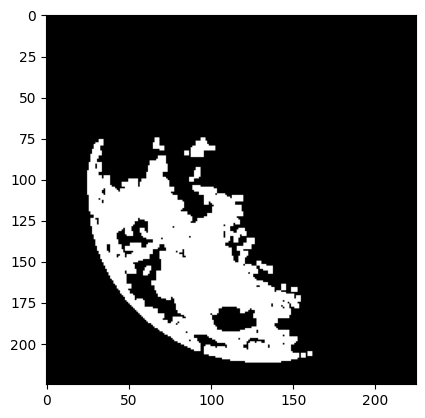

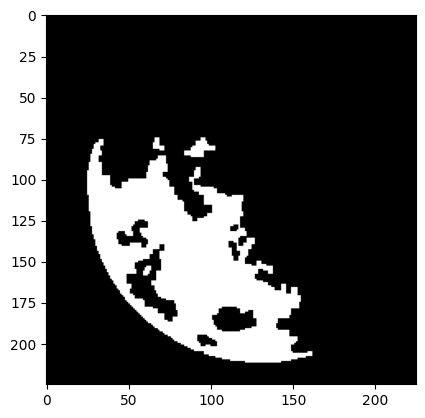

In [28]:
#Teste abertura + fechamento
kernel = criar_kernel("retangulo", 3)
img_fingerprint_aberta = abertura(img_fingerprint, kernel, "branco")
img_fingerprint_fechada = fechamento(img_fingerprint_aberta, kernel, "branco")


plt.imshow(img_fingerprint, cmap='gray')
plt.show()

plt.imshow(img_fingerprint_aberta, cmap='gray')
plt.show()

plt.imshow(img_fingerprint_fechada, cmap='gray')
plt.show()

